In [2]:
import rdata
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [3]:
# --- 1. CARGAR LOS DATOS CON RDATA ---
# Parsear y convertir el archivo RData
parsed = rdata.parser.parse_file('listings.RData')
converted = rdata.conversion.convert(parsed)

In [10]:
df = converted['listings'] # Aquí es donde se define 'df'
print(df.columns.tolist())

[np.str_('id'), np.str_('listing_url'), np.str_('scrape_id'), np.str_('last_scraped'), np.str_('source'), np.str_('name'), np.str_('description'), np.str_('neighborhood_overview'), np.str_('picture_url'), np.str_('host_id'), np.str_('host_url'), np.str_('host_name'), np.str_('host_since'), np.str_('host_location'), np.str_('host_about'), np.str_('host_response_time'), np.str_('host_response_rate'), np.str_('host_acceptance_rate'), np.str_('host_is_superhost'), np.str_('host_thumbnail_url'), np.str_('host_picture_url'), np.str_('host_neighbourhood'), np.str_('host_listings_count'), np.str_('host_total_listings_count'), np.str_('host_verifications'), np.str_('host_has_profile_pic'), np.str_('host_identity_verified'), np.str_('neighbourhood'), np.str_('neighbourhood_cleansed'), np.str_('neighbourhood_group_cleansed'), np.str_('latitude'), np.str_('longitude'), np.str_('property_type'), np.str_('room_type'), np.str_('accommodates'), np.str_('bathrooms'), np.str_('bathrooms_text'), np.str_(

In [11]:

if df['price'].dtype == 'O':  # Si es un "Object" (texto)
    df['price'] = df['price'].replace({r'\$': '', ',': ''}, regex=True)
    
df['price'] = pd.to_numeric(df['price'], errors='coerce')

# Ahora sí volvemos a generar num_vars (incluyendo el precio ya corregido)
num_vars = df.select_dtypes(include=['float64', 'int64', 'float32', 'int32']).dropna()

In [12]:
print("Objetos en el RData:", converted.keys())
# Asignar el dataframe
##df = converted['listings']

# Ver estructura para tu diccionario de variables
print("\n--- Información del Dataset ---")
df.info()

Objetos en el RData: dict_keys(['listings'])

--- Información del Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 171748 entries, 1 to 171748
Data columns (total 80 columns):
 #   Column                                        Non-Null Count   Dtype  
---  ------                                        --------------   -----  
 0   id                                            171748 non-null  float64
 1   listing_url                                   171748 non-null  string 
 2   scrape_id                                     171748 non-null  float64
 3   last_scraped                                  171748 non-null  string 
 4   source                                        171748 non-null  string 
 5   name                                          171748 non-null  string 
 6   description                                   171748 non-null  string 
 7   neighborhood_overview                         171748 non-null  string 
 8   picture_url                                   

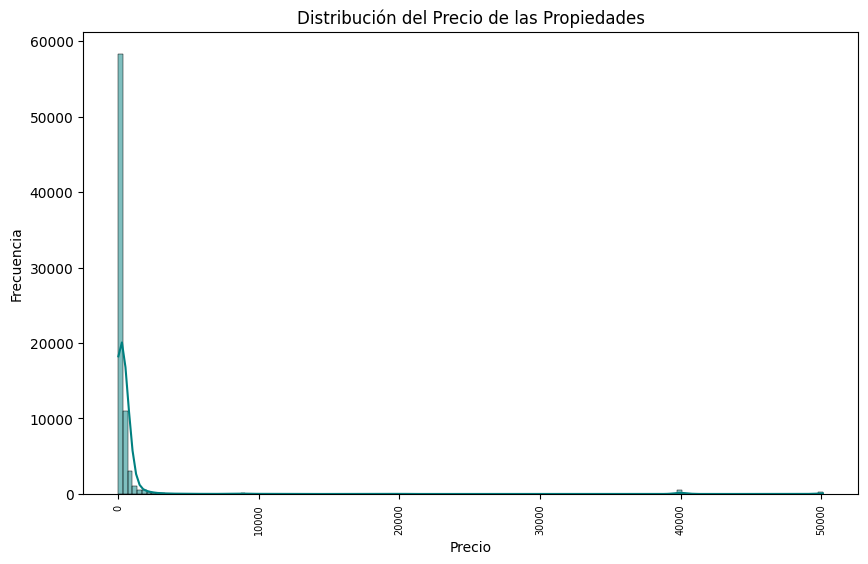

poner comentario sobre la grafica de distribución del precio


In [13]:
# --- 2. ANÁLISIS EXPLORATORIO: Distribución del precio ---
plt.figure(figsize=(10, 6))
sns.histplot(df['price'].dropna(), bins=150, kde=True, color='teal')
plt.title('Distribución del Precio de las Propiedades')
plt.xlabel('Precio')
plt.xticks(rotation=90,fontsize=7)
plt.ylabel('Frecuencia')
plt.show()
print("poner comentario sobre la grafica de distribución del precio")

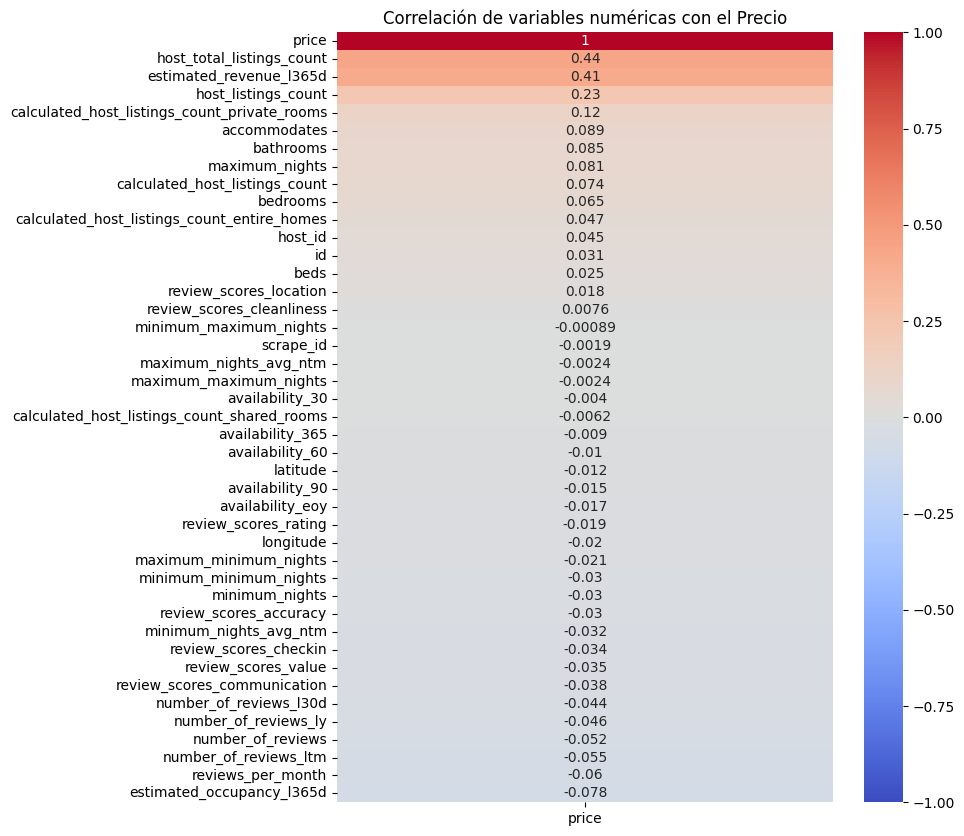

In [14]:
##--- 3. ANÁLISIS DE RELACIONES (Con la variable respuesta: precio) ---
# Extraer numéricas y quitar NAs temporalmente para la matriz
num_vars = df.select_dtypes(include=['float64', 'int64', 'float32', 'int32']).dropna()

plt.figure(figsize=(8, 10))
# Enfocarnos solo en qué afecta al precio
correlacion_precio = num_vars.corr()[['price']].sort_values(by='price', ascending=False)
sns.heatmap(correlacion_precio, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlación de variables numéricas con el Precio')
plt.show()


In [15]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# --- 4. ANÁLISIS DE GRUPOS (Clustering K-Means) ---
# 1. Escalar los datos (ESTA ES LA LÍNEA QUE FALTABA)
scaler = StandardScaler()
datos_escalados = scaler.fit_transform(num_vars)

# 2. Agrupamos en 3 perfiles
kmeans = KMeans(n_clusters=3, random_state=42)
num_vars['cluster'] = kmeans.fit_predict(datos_escalados)

# 3. Mostrar características promedio de los grupos
print("\n--- Características promedio por Grupo (Cluster) ---")
promedios_grupos = num_vars.groupby('cluster').mean()

# Imprimir solo algunas columnas clave para que sea fácil de interpretar
columnas_clave = [col for col in ['price', 'accommodates', 'bedrooms', 'bathrooms', 'review_scores_rating'] if col in num_vars.columns]
print(promedios_grupos[columnas_clave])


--- Características promedio por Grupo (Cluster) ---
               price  accommodates  bedrooms  bathrooms  review_scores_rating
cluster                                                                      
0        1375.386946      4.805102  1.636364   1.677415              4.441865
1         221.949439      4.206859   1.53994   1.392062              4.874350
2         346.331199      5.506588  2.115174   1.781847              4.837105
